> ⚠️ **This notebook uses [PyTorch](https://pytorch.org/).** Install it with `pip install -e '.[frameworks]'` to re-execute it. The published page shows *committed* outputs: the documentation build is framework-free and renders this notebook without running it, while the `framework-notebooks` CI job installs PyTorch and executes it end to end — that job, not the docs build, is the gate that keeps the outputs on this page honest.

# Language modeling and sampling: train a character model, then turn the temperature knob

**Purpose.** Turn "a language model predicts the next token" from a definition into a model you have trained and sampled from. You will watch a character model's confusion fall from *guessing uniformly among 18 characters* to *choosing between fewer than four*, generate novel words from it, and then discover that one number — the **temperature** — slides those samples between cautious and reckless without touching a single weight.

**Prerequisites.** The vanilla RNN cell and backpropagation through time, ideally through the sibling notebook [Recurrent neural networks](../01-recurrent-neural-networks/), whose cell this model is built on. You do **not** need to know PyTorch: every equation, shape, and gradient this notebook relies on is derived in the [explanation](../../explanation/language-modeling-and-sampling/) and pinned in the [reference](../../reference/language-modeling-and-sampling/), and every model, loss, and sampler is imported ready-made.

**What you will be able to do by the end.**

- Read a language model's **per-character cross-entropy** and **perplexity**, and recognise the $\ln V$ and $V$ an *untrained* model must sit at.
- Train the model and read its loss curve as *the effective number of characters it is choosing between*.
- Sample novel sequences autoregressively, and reproduce a sampled string byte-for-byte from its seed.
- Predict what the **temperature** does to a sample before you turn it, and read the fidelity-versus-diversity trade-off straight off a plot.

**What this notebook is not.** It does not implement a language model. The RNN cell, the softmax read-out, the shifted-target cross-entropy, the training loop with gradient clipping, and the autoregressive sampler are all imported from the hub's canonical PyTorch module `dlhub.pytorch.sequence.language_model` — the same code the reference documents and `tests/test_language_model.py` checks. This notebook only *drives* that module and reads what comes back, so the lesson cannot drift from the implementation.

**A note on the framework.** This is the hub's first *framework-canonical* topic. Everywhere else the hub teaches from a from-scratch NumPy reference and treats a framework as a port; here PyTorch is the only implementation, because a character language model introduces no new differentiable mathematics of its own — the RNN cell's backprop is owned by the recurrent-neural-networks topic (the [sibling notebook](../01-recurrent-neural-networks/) builds on the same cell), and everything this one adds — the training loop, the sampler — is orchestration a framework does not hide. So we import PyTorch and lose nothing.

**Runtime.** About twenty seconds on a laptop CPU — almost all of it importing PyTorch and running 300 training steps; nothing here wants a GPU. **Seed.** `torch.manual_seed(1)` fixes the initial weights (inside `build_model`), and a `torch.Generator` seeded `1` drives every sample, so every number and every string below is reproducible on any machine.

### Where this fits

| Reader wants to | Go to |
| --- | --- |
| Learn it step by step | **This notebook** — you are here |
| Do it in a project | [Train a language model](../../how-to/train-a-language-model/) |
| Look up the factorisation or sampling algorithm | [Language modeling and sampling (reference)](../../reference/language-modeling-and-sampling/) |
| Understand why it works | [Language modeling and sampling (explanation)](../../explanation/language-modeling-and-sampling/) |
| Learn by running it | **This notebook** — you are here |

## 1. Orient: a language model is a product of guesses

A **language model** assigns a probability to a sequence by predicting one token at a time, each prediction conditioned on everything before it. Written out, the joint probability of a string factorises into a product of next-character guesses:

$$P\big(x^{\langle 1\rangle}, \dots, x^{\langle T\rangle}\big) = \prod_{t=1}^{T} P\big(x^{\langle t\rangle} \mid x^{\langle 1\rangle}, \dots, x^{\langle t-1\rangle}\big).$$

We work at the **character** level, so a "token" is a single character and the vocabulary is small enough to read. The RNN supplies each factor: its read-out $\hat{y}^{\langle t\rangle} = \mathrm{softmax}\big(W_{ya}\,a^{\langle t\rangle} + b_y\big)$ is the distribution over the *next* character, and training pushes that distribution toward the character that actually came next.

The corpus is a fixed literal of ten short animal names, one per line — small enough that training finishes in a blink and every result on the page is pinned. The vocabulary is the **sorted** set of characters it contains, newline included (the newline is how the model learns to end a word). Build the fixture and look at it.

In [1]:
import math

import matplotlib.pyplot as plt
import torch

from dlhub.pytorch.sequence.language_model import (
    CORPUS,
    build_model,
    corpus_cross_entropy,
    make_fixture,
    perplexity,
    sample,
    train,
)

fixture = make_fixture()
V = fixture["vocab_size"]

print("corpus (ten words, one per line):")
print(CORPUS)
print(f"vocabulary, sorted ({V} characters): {fixture['vocab']!r}")
print(f"n_x = n_y = V = {V}      hidden size n_a = {fixture['hidden_size']}")

corpus (ten words, one per line):
cat
dog
fish
bird
frog
bear
lion
wolf
deer
hawk

vocabulary, sorted (18 characters): ['\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'n', 'o', 'r', 's', 't', 'w']
n_x = n_y = V = 18      hidden size n_a = 32


The vocabulary is eighteen characters: the newline `'\n'` first (it sorts before every letter), then the letters that appear across the ten words. Because the model is character-level and one-hot, the input width and the output width are both $V = 18$ — it reads one of eighteen characters and predicts a distribution over the same eighteen.

Training uses **shifted targets**. At step $t$ the model sees the previous character and must predict the current one, $y^{\langle t\rangle} = x^{\langle t+1\rangle}$; the first input is the zero vector (nothing precedes the first character) and the last target is the terminating newline. That is the whole supervision signal — no labels beyond "what character came next" — and it is enough to learn the shape of a word.

## 2. The smallest meaningful example: where an untrained model sits

Before training, the model knows nothing, so its safest guess is to spread probability evenly across all $V$ characters. A uniform distribution over $V$ outcomes has cross-entropy $\ln V$ nats and **perplexity** $\exp(\ln V) = V$ — perplexity is just the exponential of the cross-entropy, read as *the effective number of characters the model is choosing between*. So an untrained model should score close to $\ln V \approx 2.89$ nats and a perplexity of about $18$. This is not a target we set; it is a consequence of the initialisation, and it is the first thing to check, because a model that starts far from it has a bug.

In [2]:
model = build_model(V, fixture["hidden_size"])  # torch.manual_seed(1) fixes the weights
examples = fixture["examples"]

init_ce = float(corpus_cross_entropy(model, examples).detach())
print(f"per-character cross-entropy at init : {init_ce:.4f} nats")
print(f"ln V (uniform over {V} characters)  : {math.log(V):.4f} nats")
print(f"perplexity at init                  : {perplexity(init_ce):.2f}   (V = {V})")


def draw_samples(n, temperature, seed=fixture["sample_seed"]):
    """Draw n strings from one generator seeded `seed`, so the whole run reproduces."""
    generator = torch.Generator().manual_seed(seed)
    return [
        sample(
            model,
            fixture["char_to_ix"],
            fixture["ix_to_char"],
            generator=generator,
            temperature=temperature,
        ).strip()
        for _ in range(n)
    ]


untrained_samples = draw_samples(6, temperature=1.0)
print("\nsix samples from the untrained model (T = 1.0, seed 1):")
print(untrained_samples)
print(f"identical when the seed is reset: {untrained_samples == draw_samples(6, 1.0)}")

per-character cross-entropy at init : 2.8956 nats
ln V (uniform over 18 characters)  : 2.8904 nats
perplexity at init                  : 18.09   (V = 18)

six samples from the untrained model (T = 1.0, seed 1):
['', 'gdehfeoagicn', 'dadgftodwewsa', 'fishieawkidwbothabflosct', 'gg', '']
identical when the seed is reset: True


Two things landed. First, the per-character cross-entropy at initialisation is about **2.90 nats** against a $\ln V$ of **2.89**, and the perplexity is about **18.1** against a $V$ of **18** — the untrained model really is sitting on the uniform distribution, exactly where the mathematics says it must. This is the correctness anchor for everything that follows: the number the loss *starts* at is not arbitrary.

Second, the samples are nonsense — random-length character salad like `gdehfeoagicn`, with a couple of empty strings where the model happened to draw the terminating newline first. That is exactly what sampling from a near-uniform distribution should produce. But it is **reproducible** nonsense: reset the generator to the same seed and the identical six strings come back, because the generator is passed into `sample` explicitly rather than read from global state. That reproducibility is what makes a sampled sequence a fact you can quote and re-derive, and it is what lets the temperature experiment below compare like with like.

## 3. Watch it learn: loss, perplexity, and the clip that guards the descent

Now train. `train` runs full-corpus gradient descent for a fixed number of steps: at each step it evaluates the per-character cross-entropy over all ten words, backpropagates through time, **clips the global gradient norm**, and takes one SGD step. Clipping is the exploding-gradient remedy the [recurrent-neural-networks](../01-recurrent-neural-networks/) topic derived — one L2 norm over every gradient at once, rescaled if it exceeds a threshold — and it is built into the loop here rather than bolted on. Three hundred steps is plenty for a corpus this size and runs in about a second.

cross-entropy  2.8956  ->  1.2964 nats
perplexity     18.09  ->   3.66


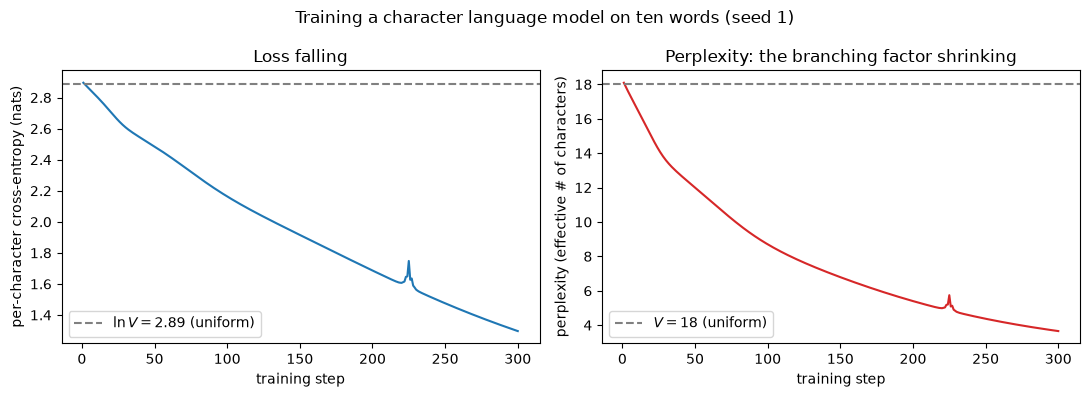

In [3]:
history = train(
    model, examples, steps=300
)  # clips the global grad norm at 5.0 each step

print(f"cross-entropy  {history[0]:.4f}  ->  {history[-1]:.4f} nats")
print(
    f"perplexity     {perplexity(history[0]):5.2f}  ->  {perplexity(history[-1]):5.2f}"
)

steps = range(1, len(history) + 1)
perp = [perplexity(loss) for loss in history]

fig, (ax_ce, ax_pp) = plt.subplots(1, 2, figsize=(11, 4))

ax_ce.plot(steps, history, color="#1f77b4")
ax_ce.axhline(
    math.log(V), ls="--", color="grey", label=rf"$\ln V = {math.log(V):.2f}$ (uniform)"
)
ax_ce.set_xlabel("training step")
ax_ce.set_ylabel("per-character cross-entropy (nats)")
ax_ce.set_title("Loss falling")
ax_ce.legend()

ax_pp.plot(steps, perp, color="#d62728")
ax_pp.axhline(V, ls="--", color="grey", label=f"$V = {V}$ (uniform)")
ax_pp.set_xlabel("training step")
ax_pp.set_ylabel("perplexity (effective # of characters)")
ax_pp.set_title("Perplexity: the branching factor shrinking")
ax_pp.legend()

fig.suptitle("Training a character language model on ten words (seed 1)")
fig.tight_layout()
plt.show()

**What to notice.** Both curves start exactly where the anchor predicted — cross-entropy at $\ln V$, perplexity at $V$ — and fall steeply. By step 300 the per-character cross-entropy is about **1.30 nats** and the perplexity about **3.7**: the model has gone from *choosing between eighteen characters* to *choosing between fewer than four*. That is what a language model learning the structure of its corpus looks like as a number — not "it got the words right," but "it narrowed its guesses."

The loss falls smoothly, with no spikes, which raises a fair question about the clipping: did it ever do anything? Measure the global gradient norm — the quantity `train` compares against its threshold of 5.0 — and find out.

In [4]:
def global_grad_norm(a_model):
    """Read the L2 norm of all gradients as one vector, clipping nothing (threshold = inf)."""
    a_model.zero_grad()
    corpus_cross_entropy(a_model, examples).backward()
    return float(torch.nn.utils.clip_grad_norm_(a_model.parameters(), float("inf")))


untrained_model = build_model(
    V, fixture["hidden_size"]
)  # same seed, before any training
print(f"clip threshold (max_norm)         : 5.000")
print(f"global grad norm, untrained model : {global_grad_norm(untrained_model):.3f}")
print(f"global grad norm, trained model   : {global_grad_norm(model):.3f}")

clip threshold (max_norm)         : 5.000
global grad norm, untrained model : 0.314
global grad norm, trained model   : 0.179


**Honest reading.** The gradient norm is about **0.31** at the start and stays a small fraction of the 5.0 threshold throughout — so on this gentle ten-word corpus the clip **never engages**. It is dormant insurance, not the reason training worked.

That is worth saying plainly rather than dressing up: clipping did not save this run, because nothing here threatened to explode. Its value shows up on the long sequences and larger learning rates where the recurrence *does* drive the norm up by orders of magnitude between steps — the regime the [recurrent-neural-networks](../01-recurrent-neural-networks/) topic measures — and where a single unclipped step can undo all prior progress. The canonical `train` keeps the clip in the loop so the same code scales from this toy to that regime unchanged. The lesson is the *mechanism* and where the norm sits relative to the threshold, not a manufactured rescue.

With a trained model in hand, sample from it and compare against the gibberish from before.

In [5]:
print("eight samples from the trained model (T = 1.0, seed 1):")
print(draw_samples(8, temperature=1.0))

eight samples from the trained model (T = 1.0, seed 1):
['bog', 'haer', 'birn', 'dadk', 'bod', 'cish', 'fish', 'fawk']


These are not the corpus words back verbatim — the model is a 32-unit RNN trained on ten words, not a lookup table — but they are unmistakably *word-shaped*: pronounceable consonant-and-vowel runs of a plausible length that end when the model draws a newline, and a few may even be real corpus words. The untrained model produced noise; this one has learned the shape of the thing. That is the "so what" of a language model: it captures structure well enough to *generate* new instances of it.

Now for the one knob that decides how boldly it generates.

## 4. Vary exactly one thing: the temperature

Sampling divides the read-out logits by a **temperature** $T$ before the softmax:

$$p^{\langle t\rangle} = \mathrm{softmax}\big(z^{\langle t\rangle} / T\big), \qquad i^{\langle t\rangle} \sim \mathrm{Multinomial}\big(p^{\langle t\rangle}\big).$$

At $T = 1$ the model samples from its own learned distribution. As $T \to 0^{+}$ the division sharpens the distribution toward a spike on the single most likely character — greedy, repetitive, *safe*. As $T$ grows past $1$ it flattens the distribution toward uniform — surprising, varied, *reckless*. Nothing else changes: not the weights, not the seed, only $T$.

We will draw 200 samples at each of several temperatures — every batch from a `torch.Generator` seeded identically, so temperature is the *only* thing that differs between batches — and measure two things: what fraction are exact corpus words (**fidelity**), and how many are distinct (**diversity**).

**Predict before you run it.** As $T$ climbs from $0.3$ to $2.0$, what happens to the fraction of valid corpus words, and to the number of distinct strings? Which way does each move, and do they move together or in opposition? Write it down, then run the next cell.

In [6]:
corpus_words = {word for word in CORPUS.split("\n") if word}


def sample_batch(temperature, n=200, seed=fixture["sample_seed"]):
    """Draw n strings at one temperature from a single seeded generator."""
    generator = torch.Generator().manual_seed(seed)
    return [
        sample(
            model,
            fixture["char_to_ix"],
            fixture["ix_to_char"],
            generator=generator,
            temperature=temperature,
        ).strip()
        for _ in range(n)
    ]


temperatures = [0.3, 0.5, 0.8, 1.0, 1.3, 1.6, 2.0]
valid_rate = []
diversity = []
for temp in temperatures:
    batch = sample_batch(temp)
    valid_rate.append(100 * sum(word in corpus_words for word in batch) / len(batch))
    diversity.append(len(set(batch)))
    preview = list(dict.fromkeys(batch))[:8]
    print(
        f"T = {temp:<4} valid {valid_rate[-1]:5.1f}%  distinct {diversity[-1]:3d}/200  e.g. {preview}"
    )

T = 0.3  valid  23.0%  distinct  55/200  e.g. ['bion', 'fion', 'diog', 'dog', 'wog', 'fish', 'fawk', 'deer']
T = 0.5  valid  14.5%  distinct 111/200  e.g. ['bog', 'haer', 'birn', 'dad', 'fiod', 'biog', 'fish', 'fawk']


T = 0.8  valid   5.5%  distinct 180/200  e.g. ['bog', 'haer', 'birn', 'dad', 'food', 'bish', 'fish', 'fawk']
T = 1.0  valid   3.0%  distinct 190/200  e.g. ['bog', 'haer', 'birn', 'dadk', 'bod', 'cish', 'fish', 'fawk']


T = 1.3  valid   1.5%  distinct 193/200  e.g. ['bog', 'heer', 'gich', 'dadk', 'bod', 'cwsh', 'fish', 'wawk']


T = 1.6  valid   0.5%  distinct 196/200  e.g. ['bogh', 'feong', 'ce', 'dadg', 'bodw', 'wiarf', 'shikf', 'kidwr']


T = 2.0  valid   0.5%  distinct 195/200  e.g. ['bwoh', 'feongi', 'h', 'dadg', 'todw', 'wiarfns', 'ieawk', 'dwe']


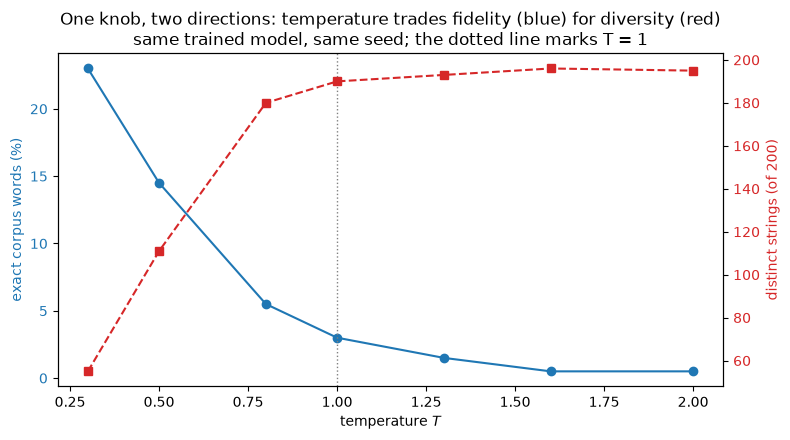

In [7]:
fig, ax_valid = plt.subplots(figsize=(8, 4.5))

color_v, color_d = "#1f77b4", "#d62728"
ax_valid.plot(temperatures, valid_rate, "o-", color=color_v)
ax_valid.set_xlabel("temperature $T$")
ax_valid.set_ylabel("exact corpus words (%)", color=color_v)
ax_valid.tick_params(axis="y", labelcolor=color_v)

ax_div = ax_valid.twinx()
ax_div.plot(temperatures, diversity, "s--", color=color_d)
ax_div.set_ylabel("distinct strings (of 200)", color=color_d)
ax_div.tick_params(axis="y", labelcolor=color_d)

ax_valid.axvline(1.0, color="grey", ls=":", lw=1)
ax_valid.set_title(
    "One knob, two directions: temperature trades fidelity (blue) for diversity (red)\n"
    "same trained model, same seed; the dotted line marks T = 1"
)
fig.tight_layout()
plt.show()

**What to notice.** The two curves move in opposition, and monotonically. At $T = 0.3$ the model plays it safe: about **23%** of samples are exact corpus words and only **55** of the 200 draws are distinct — it keeps returning to the handful of strings it is most sure of. At $T = 2.0$ it is almost all novelty and almost no fidelity: under **1%** valid, nearly **200** distinct strings, many of them unpronounceable. $T = 1$, the dotted line, is neither — it is the model reporting its own beliefs without editorialising.

This is the whole of the temperature knob. It does not make the model *know* more or less; the weights never moved. It reshapes how the model's fixed distribution is *sampled* — sharpening it toward the mode when $T$ is small, flattening it toward uniform when $T$ is large. Low temperature buys fidelity at the cost of variety; high temperature buys variety at the cost of sense. Choosing $T$ is choosing where on that trade-off to sit, and there is no single right answer: a spelling corrector wants it low, a brainstorming aid wants it high.

## 5. What this means, and what it does not

**What it means.** You have a working language model. It started at the uniform-guess anchor of $\ln V$ nats and $V$-way perplexity exactly as the mathematics requires, learned the structure of its corpus down to a perplexity under four, generated novel word-shaped strings, and handed you a single dial — temperature — that trades fidelity for diversity along a smooth, monotonic curve. Every one of those results is reproducible from a seed, because the model, the loss, and the sampler are the hub's canonical PyTorch module and the randomness is an explicitly-passed generator.

**What it does not mean.** Four honest limits, each one visible above.

- **The model did not memorise the corpus, and it is not supposed to.** A 32-unit RNN on ten words learns *shape*, not a word list; even at low temperature most samples are plausible non-words. Perplexity under four is the model narrowing its guesses, not achieving perfection.
- **Temperature changes sampling, not knowledge.** The weights are frozen while you turn the knob. High temperature does not make the model more creative in any deep sense; it makes the *sampler* draw further into the tails of a fixed distribution.
- **Nothing here exploded, so nothing here was clipped.** The clip in `train` stayed dormant on this corpus, as the gradient-norm read showed. This notebook demonstrates the *mechanism* and where the norm sits; it does not witness an exploding gradient, which lives on longer sequences and larger steps.
- **This is a vanilla RNN character model, not a large language model.** The factorisation $P(\text{sequence}) = \prod_t P(\text{next} \mid \text{past})$ is exactly the one an LLM uses, but the cell, the vocabulary, the corpus, and the scale are all toy. What carries over is the idea; what does not is everything about making it work at scale.

### Key Takeaways

1. A language model factorises a sequence into a product of next-character guesses, $P(x^{\langle 1\rangle}, \dots, x^{\langle T\rangle}) = \prod_t P(x^{\langle t\rangle} \mid x^{\langle 1\rangle}, \dots, x^{\langle t-1\rangle})$, and an RNN read-out supplies each factor.
2. An untrained model sits at the uniform anchor — per-character cross-entropy $\approx \ln V$, perplexity $\approx V$ — and checking that it does is the first test that the setup is sound.
3. Perplexity is the exponential of the per-character cross-entropy, read as the effective number of characters the model chooses between; training drove it from about 18 to under 4.
4. Sampling is autoregressive and, with an explicitly-passed seeded generator, byte-for-byte reproducible — a generated string is a fact you can quote.
5. Temperature is one knob with two directions: low $T$ sharpens toward the mode (high fidelity, low diversity), high $T$ flattens toward uniform (high diversity, low fidelity), and $T = 1$ is the model's own distribution. The weights never move.
6. Global-norm gradient clipping is built into the training loop as the exploding-gradient guardrail from the recurrent-neural-networks topic; on a corpus this gentle it never engages, and the notebook says so rather than staging a rescue.

Continue with the [explanation](../../explanation/language-modeling-and-sampling/) for the derivations behind the factorisation, the shifted-target training, and why temperature works; the [reference](../../reference/language-modeling-and-sampling/) for every equation, shape, and the sampling algorithm in lookup form; or [train a language model](../../how-to/train-a-language-model/) to put one into a project of your own.